# Notebook 1 — Memory-Based vs Path-Based Loading

This notebook compares two strategies for loading satellite imagery into memory:
- **Strategy 1 — Memory-Based:** Load all images into RAM at once as NumPy arrays
- **Strategy 2 — Path-Based (Generator):** Store only file paths; read images on demand

Run this notebook first to understand the trade-offs before choosing a pipeline for training.

In [1]:
%%time
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
CPU times: total: 7.17 s
Wall time: 7.28 s


In [2]:
import os
from pathlib import Path
from PIL import Image
import psutil
import matplotlib.pyplot as plt
import numpy as np

In [3]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

class_0_non_agri is the non-agricultural land class, as defined earlier, and it represents images with non-cultivable land.
class_1_agri, on the other hand, is the agricultural land class, and it represents the images with cultivable land.

**os.scandir** to build an iterator

In [4]:
non_agri = os.scandir(dir_non_agri)

for i in range(3):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>


In [5]:
file_name = next(non_agri)
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'

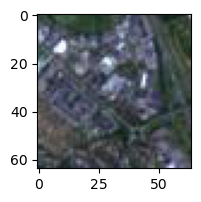

In [6]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data.shape
plt.figure(figsize=(4, 2))
plt.imshow(image_data)

<b>Strategy 1 — Memory-Based Loading</b><br>
Load every single image from disk into RAM at once, store them all as a big NumPy array.

In [7]:
def get_ram_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  

In [8]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = []
non_agri = os.scandir(dir_non_agri)

for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri,image_name))
        non_agri_images.append(image_data)

non_agri_images = np.array(non_agri_images)        

after_ram = get_ram_usage_mb()
print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: 38.11 MB
CPU times: total: 2.28 s
Wall time: 2.29 s


In [9]:
agri_images = []

for entry in os.scandir(dir_agri):
    if entry.is_file():
        image_data = plt.imread(entry.path)
        agri_images.append(image_data)

agri_images = np.array(agri_images)

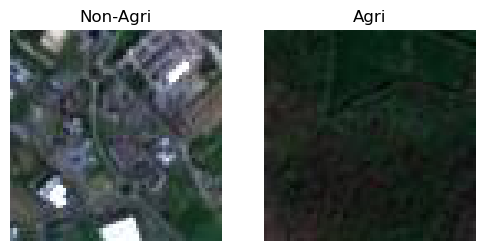

In [10]:
plt.figure(figsize=(6, 3))

# Left image (non-agri)
plt.subplot(1, 2, 1)
plt.imshow(non_agri_images[1])
plt.title("Non-Agri")
plt.axis('off')

# Right image (agri)
plt.subplot(1, 2, 2)
plt.imshow(agri_images[1])
plt.title("Agri")
plt.axis('off')

plt.show()

<b>Strategy 2 — Generator/Path-Based </b><br>
Store only the file paths (strings) in memory. Open each image only when you actually need it — one at a time or one batch at a time.

In [11]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = os.listdir(dir_non_agri) #listdir gives names only
non_agri_images.sort()
non_agri_images_paths = [os.path.join(dir_non_agri,image) for image in non_agri_images]

after_ram = get_ram_usage_mb()

print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: -34.26 MB
CPU times: total: 46.9 ms
Wall time: 27.1 ms


Looking at the results of psutil and %%time , Path based generator will be better in terms of memory required

In [12]:
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [13]:
non_agri_images_paths[:5]

['..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [14]:
len(non_agri_images_paths)

3000

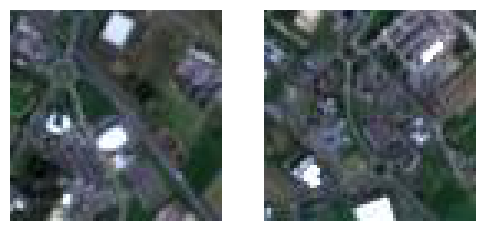

In [15]:
plt.figure(figsize=(6, 3))

for i in range(2):
    img = Image.open(non_agri_images_paths[i])

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [16]:
agri_images = os.listdir(dir_agri)
agri_images.sort()
agri_images_paths = [os.path.join(dir_agri,image) for image in agri_images]
len(agri_images_paths)

3000

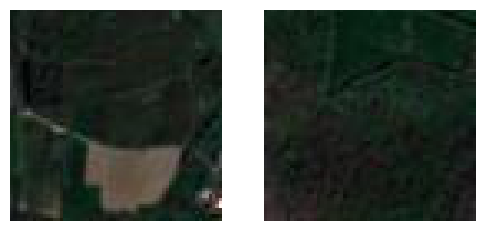

In [17]:
plt.figure(figsize=(6,3))

for i in range(2):
    img = Image.open(agri_images_paths[i])
    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [18]:
(PROJECT_ROOT, RAW_DIR, dir_agri, dir_non_agri)

('..',
 '..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')